In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

d:\PredictiveMaintainance\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
%pip install streamlit
%pip install shap
%pip install joblib

In [2]:
df = pd.read_csv(r'dataset\predictive_maintenance.csv')

X = df.drop(columns=['Target', 'Failure Type', 'UDI', 'Product ID'])
y = df['Target']

X = X.rename(columns={
    'Air temperature [K]': 'Air_temperature_K',
    'Process temperature [K]': 'Process_temperature_K',
    'Rotational speed [rpm]': 'Rotational_speed_rpm',
    'Torque [Nm]': 'Torque_Nm',
    'Tool wear [min]': 'Tool_wear_min'
})

X['Temp_Diff'] = (
    X['Process_temperature_K']
    - X['Air_temperature_K']
)

X['Torque_Wear'] = (
    X['Torque_Nm']
    * X['Tool_wear_min']
)

X['Torque_RPM'] = (
    X['Torque_Nm']
    * X['Rotational_speed_rpm']
)

X = pd.get_dummies(
    X,
    columns=['Type'],
    drop_first=True
)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
rf = joblib.load("random_forest_model.pkl")

In [6]:
xgb = joblib.load("xgboost_model.pkl")

In [7]:
explainer_xgb = shap.TreeExplainer(xgb)

shap_values_xgb = explainer_xgb.shap_values(X_test)


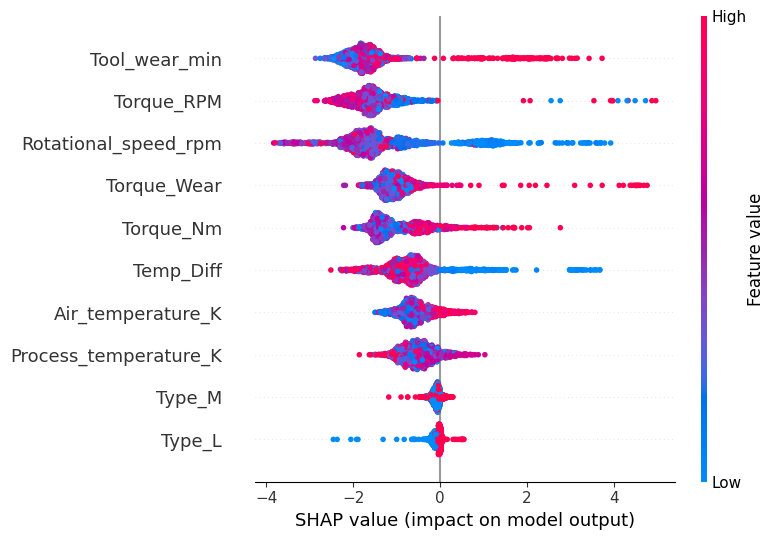

In [8]:
shap.summary_plot(
    shap_values_xgb,
    X_test
)

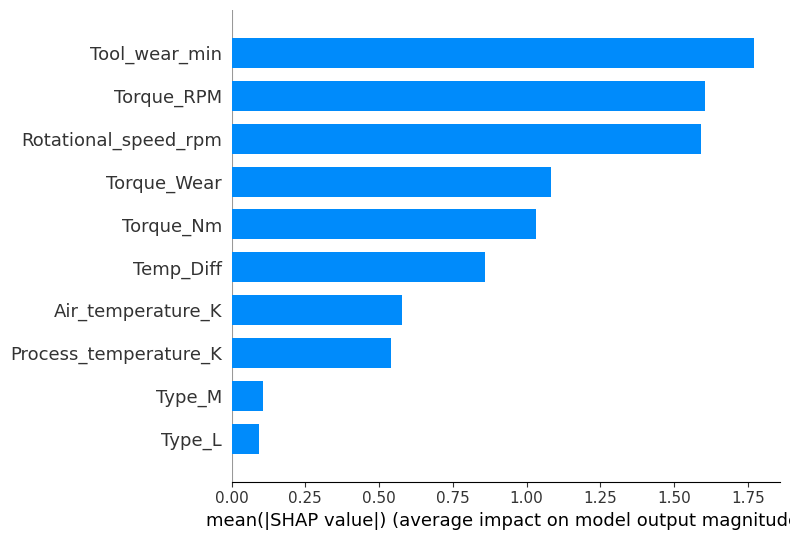

In [9]:
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type='bar'
)

In [10]:
explainer_rf = shap.TreeExplainer(rf)

shap_values_rf = explainer_rf.shap_values(X_test)

In [11]:
print(type(shap_values_rf))

<class 'numpy.ndarray'>


In [12]:
shap_values_rf = shap_values_rf[1]

In [13]:
shap.summary_plot(
    shap_values_rf,
    X_test
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [14]:
shap.summary_plot(
    shap_values_rf,
    X_test,
    plot_type='bar'
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [15]:
i = 0

shap.force_plot(
    explainer_rf.expected_value,
    shap_values_rf[i],
    X_test.iloc[i],
    matplotlib=True
)

DimensionError: Length of features is not equal to the length of shap_values!